# Antenna Design Using Deep Learning


In [1]:
# Imports
import torch, os, os.path as osp
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
import numpy as np
import scipy.io
print(torch.cuda.is_available())

import torch
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

True


Import the data file. Here the training and test data are stored in matlab

In [3]:
from google.colab import drive
drive.mount('/content/drive')
filepath = '/content/drive/MyDrive/My_models/antenna_dataset_enriched.mat'

Mounted at /content/drive


Split the training and test data set accordingly. The function returns dataloader that splits the data according to the batch size.

In [4]:
# API to load the saved dataset file
def get_dataloader_from_pth(file_name,batch_size=4,set_name='train'):
    print('loading '+set_name+' data....')

    mat = scipy.io.loadmat(file_name)

    # #tset train split
    # xdata= mat['Test_patchesd'] # for filepath 2
    # # xdata = mat['xdata']
    # xtrain = xdata[0:4500,:,:,:]
    # xval   = xdata[4500:5500,:,:,:]
    # xtest  = xdata[5500:6500,:,:,:]


    # ydata = mat['specd'] # for filepath 2
    # # ydata = mat['ydata']
    # ytrain = ydata[:,0:4500].T
    # yval   = ydata[:,4500:5500].T
    # ytest  = ydata[:,5500:6500].T

    # # tset train split
    # xdata= mat['Test_patchesd'] # for filepath 2
    # # xdata = mat['xdata']
    # xtrain = xdata[0:6500,:,:,:]
    # xval   = xdata[6500:7500,:,:,:]
    # xtest  = xdata[7500:8000,:,:,:]


    # ydata = mat['specd'] # for filepath 2
    # # ydata = mat['ydata']
    # ytrain = ydata[:,0:6500].T
    # yval   = ydata[:,6500:7500].T
    # ytest  = ydata[:,7500:8000].T

    # tset train split
    xdata = mat['XTrain1']
    ydata = mat['YTrain']
    N = xdata.shape[0]
    n_tr = int(N*0.85); n_va = int(N*0.925)      # 85% train / 7.5% val / 7.5% test
    xtrain, xval, xtest = xdata[:n_tr], xdata[n_tr:n_va], xdata[n_va:]
    ytrain = ydata[:, :n_tr].T
    yval   = ydata[:, n_tr:n_va].T
    ytest  = ydata[:, n_va:].T



# 0:47000; 47000:53000; 53000:59000
    # # tset train split
    # xdata= mat['Test_patchesd'] # for filepath 2
    # # xdata = mat['xdata']
    # xtrain = xdata[0:63600,:,:,:]
    # xval   = xdata[63600:71550,:,:,:]
    # xtest  = xdata[71550:79500,:,:,:]


    # # ydata = mat['specd'] # for filepath 2
    # # # ydata = mat['ydata']
    # ytrain = ydata[:,0:63600].T
    # yval   = ydata[:,63600:71550].T
    # ytest  = ydata[:,71550:79500].T


    if (set_name == 'train'):
      contents = {"x": torch.Tensor(xtrain),"y": torch.Tensor(ytrain)}
    elif (set_name == 'test'):
      contents = {"x": torch.Tensor(xtest),"y": torch.Tensor(ytest)}
    else:
      contents = {"x": torch.Tensor(xval),"y": torch.Tensor(yval)}


    # create dataset and dataloader
    dataset = torch.utils.data.TensorDataset(contents['x'], contents['y'])
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
    print(set_name+' data loading complete')

    return dataloader

trainloader = get_dataloader_from_pth(filepath,batch_size=256, set_name = 'train')
valloader   = get_dataloader_from_pth(filepath,batch_size=256, set_name = 'val')
testloader  = get_dataloader_from_pth(filepath,batch_size=256, set_name = 'test')


loading train data....
train data loading complete
loading val data....
val data loading complete
loading test data....
test data loading complete


 # Forward Network - Large

 Load the best forward network -- i.e initialise the network and the optimizer used while training the forward network. Load using state.load

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_filters = [1,64,128,256,1000,500,81]
kernels  = [5,5,5,3,3,3,3]
class Net_big(nn.Module):
  def __init__(self):
      super(Net_big, self).__init__()

      #padding=(1,1)
      # self.pool = nn.MaxPool2d(kernel_size=2, stride=1)
      self.conv1  = nn.Conv2d(in_channels=num_filters[0],  out_channels = num_filters[1], kernel_size=kernels[0],padding = 'same')
      self.conv2  = nn.Conv2d(in_channels=num_filters[1],  out_channels = num_filters[1], kernel_size=kernels[1],padding='same')
      self.conv3  = nn.Conv2d(in_channels=num_filters[1],  out_channels = num_filters[1], kernel_size=kernels[2],padding='same')
      self.conv4  = nn.Conv2d(in_channels=num_filters[1],  out_channels = num_filters[2], kernel_size=kernels[3],padding='same')
      self.conv5  = nn.Conv2d(in_channels=num_filters[2],  out_channels = num_filters[2], kernel_size=kernels[3],padding='same')
      self.conv6  = nn.Conv2d(in_channels=num_filters[2],  out_channels = num_filters[2], kernel_size=kernels[3],padding='same')
      self.conv7  = nn.Conv2d(in_channels=num_filters[2],  out_channels = num_filters[2], kernel_size=kernels[3],padding='same')
      self.conv8  = nn.Conv2d(in_channels=num_filters[2],  out_channels = num_filters[2], kernel_size=kernels[3],padding='same')
      self.conv9  = nn.Conv2d(in_channels=num_filters[2],  out_channels = num_filters[3], kernel_size=kernels[4],padding='same')
      self.conv10  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[4],padding='same')
      self.conv11  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')
      self.conv12  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')
      self.conv13  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')
      self.conv14  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')
      self.conv15  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')
      self.conv16  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')


      self.fc17 = nn.Linear(in_features=num_filters[3]*12*12, out_features=num_filters[4])
      self.fc18 = nn.Linear(in_features=num_filters[4], out_features=num_filters[5])
      self.fc19 = nn.Linear(in_features=num_filters[5], out_features=num_filters[6])


      self.bn1  = nn.BatchNorm2d(num_features=num_filters[1])
      self.bn2  = nn.BatchNorm2d(num_features=num_filters[1])
      self.bn3  = nn.BatchNorm2d(num_features=num_filters[1])
      self.bn4  = nn.BatchNorm2d(num_features=num_filters[2])
      self.bn5  = nn.BatchNorm2d(num_features=num_filters[2])
      self.bn6  = nn.BatchNorm2d(num_features=num_filters[2])
      self.bn7  = nn.BatchNorm2d(num_features=num_filters[2])
      self.bn8  = nn.BatchNorm2d(num_features=num_filters[2])
      self.bn9  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn10  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn11  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn12  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn13  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn14  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn15  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn16  = nn.BatchNorm2d(num_features=num_filters[3])


      self.bn17  = nn.BatchNorm1d(num_features=num_filters[4])
      self.bn18 = nn.BatchNorm1d(num_features=num_filters[5])
      self.bn19 = nn.BatchNorm1d(num_features=num_filters[6])

      self.dropout = nn.Dropout(0.4)

  def forward(self, x):
      x = F.leaky_relu(self.bn1(self.conv1(x)))
      x = F.leaky_relu(self.bn2(self.conv2(x)))
      x = F.leaky_relu(self.bn3(self.conv3(x)))
      x = F.leaky_relu(self.bn4(self.conv4(x)))
      x = F.leaky_relu(self.bn5(self.conv5(x)))
      x = F.leaky_relu(self.bn6(self.conv6(x)))
      x = F.leaky_relu(self.bn7(self.conv7(x)))
      x = F.leaky_relu(self.bn8(self.conv8(x)))
      x = F.leaky_relu(self.bn9(self.conv9(x)))
      x = F.leaky_relu(self.bn10(self.conv10(x)))
      x = F.leaky_relu(self.bn11(self.conv11(x)))
      x = F.leaky_relu(self.bn12(self.conv12(x)))
      x = F.leaky_relu(self.bn13(self.conv13(x)))
      x = F.leaky_relu(self.bn14(self.conv14(x)))
      x = F.leaky_relu(self.bn15(self.conv15(x)))
      x = F.leaky_relu(self.bn16(self.conv16(x)))


      #x = (F.relu(self.bn4(self.conv4(x))))
      #x = self.pool(F.relu(self.bn5(self.conv5(x))))
      #x = (F.relu(self.bn6(self.conv6(x))))
      #x = F.avg_pool2d(x, kernel_size=x.shape[2:])
      #x = x.view(x.shape[0], -1)
      x = torch.flatten(x, 1)
      x = self.dropout(F.leaky_relu(self.bn17(self.fc17(x))))
      x = F.leaky_relu(self.bn18(self.fc18(x)))

      #x = F.relu(self.fc2(x))
      x = self.fc19(x)
      return x
net = Net_big()
  # transfer the model to GPU
if torch.cuda.is_available():
    net = net.cuda()



# Load the pre-trained model

In [6]:
criterion = nn.MSELoss()
optimizer = optim.NAdam(net.parameters(), lr=0.001)
filepath4 = '/content/drive/MyDrive/My_models/Forward_model_for_tandem.pth'
state = torch.load(filepath4, map_location=device)
net.load_state_dict(state['state_dict'] if 'state_dict' in state else state)

<All keys matched successfully>

In [7]:
from torchsummary import summary
summary(net, (1, 12, 12))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 12, 12]           1,664
       BatchNorm2d-2           [-1, 64, 12, 12]             128
            Conv2d-3           [-1, 64, 12, 12]         102,464
       BatchNorm2d-4           [-1, 64, 12, 12]             128
            Conv2d-5           [-1, 64, 12, 12]         102,464
       BatchNorm2d-6           [-1, 64, 12, 12]             128
            Conv2d-7          [-1, 128, 12, 12]          73,856
       BatchNorm2d-8          [-1, 128, 12, 12]             256
            Conv2d-9          [-1, 128, 12, 12]         147,584
      BatchNorm2d-10          [-1, 128, 12, 12]             256
           Conv2d-11          [-1, 128, 12, 12]         147,584
      BatchNorm2d-12          [-1, 128, 12, 12]             256
           Conv2d-13          [-1, 128, 12, 12]         147,584
      BatchNorm2d-14          [-1, 128,

In [8]:
# for param in net.parameters():
#     param.requires_grad = False
num_ftrs = net.fc19.in_features
net.fc19 = nn.Linear(num_ftrs, 81)
net = net.to(device)
# print(net)

In [9]:
for name, para in net.named_parameters():
# ...     para.requires_grad = True
  print("-"*20)
  print(f"name: {name}")
  print("values: ")
  print(para)

--------------------
name: conv1.weight
values: 
Parameter containing:
tensor([[[[-3.5036e-01,  5.7199e-02,  5.1010e-02, -1.6560e-01, -1.5367e-01],
          [-4.5006e-01, -1.2301e-01,  2.0814e-01, -9.1141e-02, -4.9415e-02],
          [-7.7547e-01, -3.6349e-01,  3.2287e-04,  1.6933e-01,  1.2340e-01],
          [-4.1000e-01, -4.0113e-02,  2.6283e-02, -1.2614e-01, -8.9284e-02],
          [-1.1389e-01, -1.5216e-01, -1.6327e-01, -1.4556e-01, -1.7178e-01]]],


        [[[ 1.0428e-02, -2.2513e-02, -9.2293e-02, -1.3554e-01, -1.8713e-01],
          [-9.4460e-02, -5.9585e-02,  1.2869e-01, -2.9807e-01, -2.8397e-01],
          [ 3.0560e-02,  2.0561e-01,  6.9025e-02,  2.4160e-01, -4.0653e-02],
          [ 1.4681e-01, -5.1008e-01,  7.1081e-01,  2.4887e-01,  2.1108e-02],
          [-3.2969e-02,  1.0923e-01,  2.2679e-01,  4.0825e-02, -1.0635e-01]]],


        [[[-1.3770e-01, -2.5657e-01, -1.2833e-01, -2.2580e-01, -1.9239e-01],
          [-2.9670e-01, -4.3166e-01,  1.7228e-01, -1.9125e-02, -9.9789e-02

In [10]:
for param in net.bn19.parameters():
    param.requires_grad = True

#Working with BN unfrozen

In [11]:
param = net.state_dict()
for name, param in net.named_parameters():
    if 'bn' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [12]:
trainable_layers = []
frozen_layers = []

#Separate layers into trainable and frozen
for name, param in net.named_parameters():
    if param.requires_grad:
        trainable_layers.append(name)
    else:
        frozen_layers.append(name)

print("Trainable layers:")
for layer in trainable_layers:
    print(layer)

print("\nFrozen layers:")
for layer in frozen_layers:
    print(layer)

Trainable layers:
bn1.weight
bn1.bias
bn2.weight
bn2.bias
bn3.weight
bn3.bias
bn4.weight
bn4.bias
bn5.weight
bn5.bias
bn6.weight
bn6.bias
bn7.weight
bn7.bias
bn8.weight
bn8.bias
bn9.weight
bn9.bias
bn10.weight
bn10.bias
bn11.weight
bn11.bias
bn12.weight
bn12.bias
bn13.weight
bn13.bias
bn14.weight
bn14.bias
bn15.weight
bn15.bias
bn16.weight
bn16.bias
bn17.weight
bn17.bias
bn18.weight
bn18.bias
bn19.weight
bn19.bias

Frozen layers:
conv1.weight
conv1.bias
conv2.weight
conv2.bias
conv3.weight
conv3.bias
conv4.weight
conv4.bias
conv5.weight
conv5.bias
conv6.weight
conv6.bias
conv7.weight
conv7.bias
conv8.weight
conv8.bias
conv9.weight
conv9.bias
conv10.weight
conv10.bias
conv11.weight
conv11.bias
conv12.weight
conv12.bias
conv13.weight
conv13.bias
conv14.weight
conv14.bias
conv15.weight
conv15.bias
conv16.weight
conv16.bias
fc17.weight
fc17.bias
fc18.weight
fc18.bias
fc19.weight
fc19.bias


In [13]:
for param_tensor in net.state_dict():
    print(param_tensor, "\t", net.state_dict()[param_tensor].size())

conv1.weight 	 torch.Size([64, 1, 5, 5])
conv1.bias 	 torch.Size([64])
conv2.weight 	 torch.Size([64, 64, 5, 5])
conv2.bias 	 torch.Size([64])
conv3.weight 	 torch.Size([64, 64, 5, 5])
conv3.bias 	 torch.Size([64])
conv4.weight 	 torch.Size([128, 64, 3, 3])
conv4.bias 	 torch.Size([128])
conv5.weight 	 torch.Size([128, 128, 3, 3])
conv5.bias 	 torch.Size([128])
conv6.weight 	 torch.Size([128, 128, 3, 3])
conv6.bias 	 torch.Size([128])
conv7.weight 	 torch.Size([128, 128, 3, 3])
conv7.bias 	 torch.Size([128])
conv8.weight 	 torch.Size([128, 128, 3, 3])
conv8.bias 	 torch.Size([128])
conv9.weight 	 torch.Size([256, 128, 3, 3])
conv9.bias 	 torch.Size([256])
conv10.weight 	 torch.Size([256, 256, 3, 3])
conv10.bias 	 torch.Size([256])
conv11.weight 	 torch.Size([256, 256, 3, 3])
conv11.bias 	 torch.Size([256])
conv12.weight 	 torch.Size([256, 256, 3, 3])
conv12.bias 	 torch.Size([256])
conv13.weight 	 torch.Size([256, 256, 3, 3])
conv13.bias 	 torch.Size([256])
conv14.weight 	 torch.Size([

In [14]:
for k,v in net.state_dict().items():
    print(k,'\n',v)

Streaming output truncated to the last 5000 lines.
          [-1.1890e-01,  9.7431e-02, -5.9010e-02]],

         [[ 1.8036e-01,  4.8729e-02, -2.3541e-01],
          [ 3.9578e-02,  1.3379e-01, -1.2141e-01],
          [-4.8229e-02,  4.3139e-02, -1.9681e-01]],

         [[-1.6568e-01,  1.6853e-01,  1.6250e-02],
          [-8.7332e-02,  3.2370e-01,  6.4091e-02],
          [-1.0475e-02,  8.7149e-03,  1.9471e-01]],

         ...,

         [[-3.3200e-01,  1.5736e-01,  7.7820e-02],
          [-3.4077e-01,  2.9044e-01,  8.4891e-03],
          [-2.7552e-01,  3.0350e-01, -7.5152e-02]],

         [[-1.9157e-01, -1.1696e-01, -1.9933e-01],
          [-4.5389e-01, -1.1185e-01, -1.4307e-01],
          [-4.5468e-01, -1.7167e-01, -4.7958e-02]],

         [[-6.3006e-02, -3.1849e-01, -2.5301e-01],
          [-1.3585e-01, -2.3565e-01, -1.7785e-01],
          [ 9.2219e-02, -8.9931e-02, -7.0998e-02]]],


        [[[ 1.2417e-01,  1.0804e-01,  2.2559e-01],
          [ 1.1513e-01,  4.5302e-02,  5.8098e-02],
  

In [15]:
# non_frozen_parameters = [p for p in net.parameters() if p.requires_grad]
# optimizer = optim.Adam(non_frozen_parameters , lr=0.001)
criterion = nn.MSELoss()
optimizer = optim.NAdam(net.parameters(), lr= 0.01)
# trainloader = get_dataloader_from_pth(filepath,batch_size=64, set_name = 'train')
# valloader   = get_dataloader_from_pth(filepath,batch_size=64, set_name = 'val')
# testloader  = get_dataloader_from_pth(filepath,batch_size=64, set_name = 'test')


# Train the pre-trained network

In [16]:
def train(trainloader, optimizer, criterion,net):
    running_loss = 0.0
    net.train()
    for i, data in enumerate(tqdm(trainloader,disable=True), 0):
        # get the inputs

        antenna, spectrum = data

        if torch.cuda.is_available():
            antenna, spectrum = antenna.cuda(), spectrum.cuda()

        # zero the parameter gradients
        optimizer.zero_grad()
        # forward + backward + optimize
        outputs = net(antenna)
        loss = criterion(outputs, spectrum)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

    return  running_loss / (len(trainloader))

def test(testloader, net):
  running_loss = 0.0
  net.eval()
  with torch.no_grad():
    for data in tqdm(testloader,disable=True):
        antenna, spectrum = data

        if torch.cuda.is_available():
            antenna, spectrum = antenna.cuda(), spectrum.cuda()

        # forward + backward + optimize
        prediction = net(antenna)
        loss = criterion(prediction, spectrum)

        # print statistics
        running_loss += loss.item()

  return running_loss / (len(testloader))

In [17]:
epoch_start = 0
import time
ts=time.time()

print('\nStart Training')
os.makedirs('./models', exist_ok=True)
#import timeit
epoch_start = 0
num_epochs = 51        # desired number of training epochs.
val_loss=np.empty(num_epochs,float)
train_loss=np.empty(num_epochs,float)

for epoch in range(epoch_start,num_epochs):  # loop over the dataset multiple times
    #print('\nepoch ', epoch + 1)
    train_loss[epoch]= train(trainloader,optimizer,criterion,net)
    val_loss[epoch] = test(valloader,net)
    print('\n epoch %d training loss: %.3f  validation loss: %.3f' % (epoch + 1, train_loss[epoch], val_loss[epoch]))

    # if (epoch > 0 and epoch % 50==0):
    #   # file_save = '/content/drive/MyDrive/forward_tl_allfinetune_f_80k_15_1_t_5_'+str(epoch)+'.pth'
    #   file_save = '/content/drive/MyDrive/forward_tl_rogers_24_t_29_56k_18_'+str(epoch)+'.pth'

    #   state = {
    #           'epoch': epoch,
    #           'state_dict': net.state_dict(),
    #           'optimizer': optimizer.state_dict(),
    #           }
    #   torch.save(state,file_save)
    #   np.savetxt('/content/drive/MyDrive/loss_forward_tl_rogers_24_t_29_56k_18_'+str(num_epochs-1)+'.txt', (train_loss, val_loss,))
print('Finished Training')
state = {'epoch': num_epochs, 'state_dict': net.state_dict(), 'optimizer': optimizer.state_dict()}
torch.save(state, '/content/drive/MyDrive/My_models/forward_enriched.pth')

te=time.time()
te-ts


Start Training

 epoch 1 training loss: 4.837  validation loss: 3.793

 epoch 2 training loss: 3.688  validation loss: 3.416

 epoch 3 training loss: 3.515  validation loss: 3.303

 epoch 4 training loss: 3.428  validation loss: 3.203

 epoch 5 training loss: 3.367  validation loss: 3.155

 epoch 6 training loss: 3.326  validation loss: 3.085

 epoch 7 training loss: 3.298  validation loss: 3.091

 epoch 8 training loss: 3.274  validation loss: 3.047

 epoch 9 training loss: 3.259  validation loss: 3.097

 epoch 10 training loss: 3.244  validation loss: 3.035

 epoch 11 training loss: 3.232  validation loss: 3.034

 epoch 12 training loss: 3.221  validation loss: 3.048

 epoch 13 training loss: 3.211  validation loss: 2.996

 epoch 14 training loss: 3.202  validation loss: 2.987

 epoch 15 training loss: 3.193  validation loss: 3.005

 epoch 16 training loss: 3.186  validation loss: 2.952

 epoch 17 training loss: 3.179  validation loss: 2.955

 epoch 18 training loss: 3.172  validati

5872.585961341858

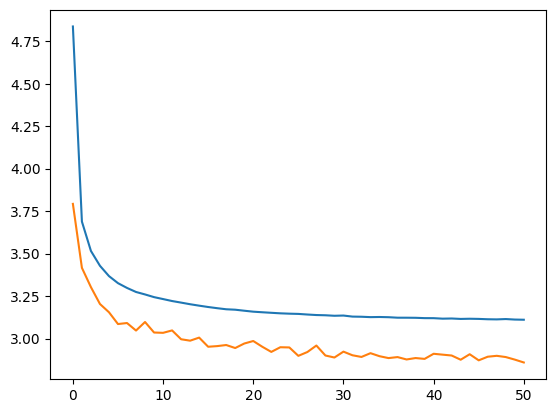

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

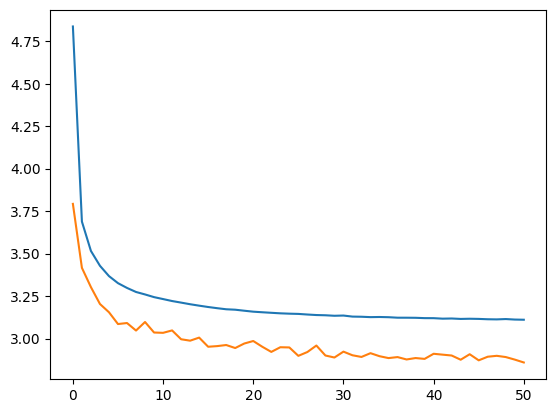

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

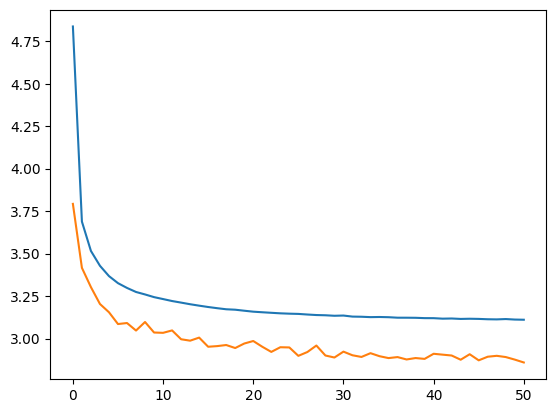

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

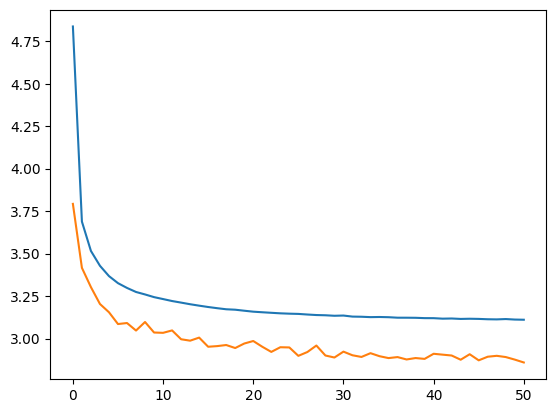

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

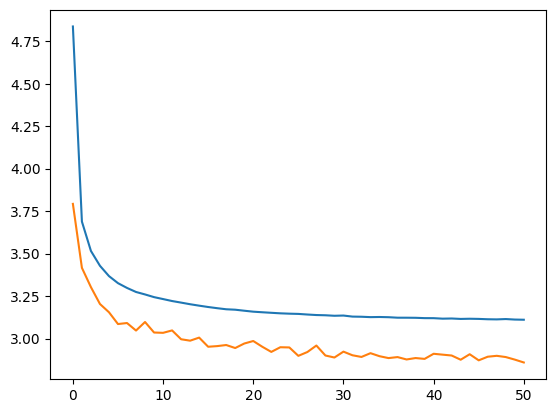

In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

#All fine-tuned

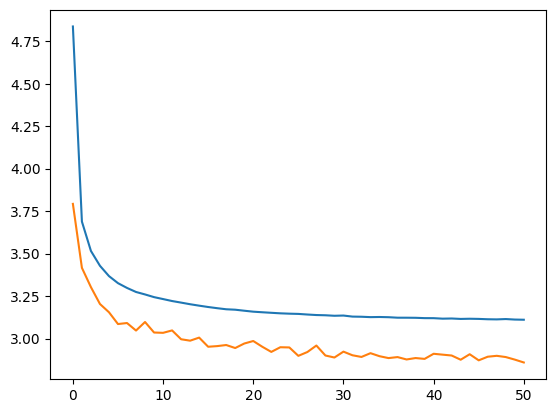

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

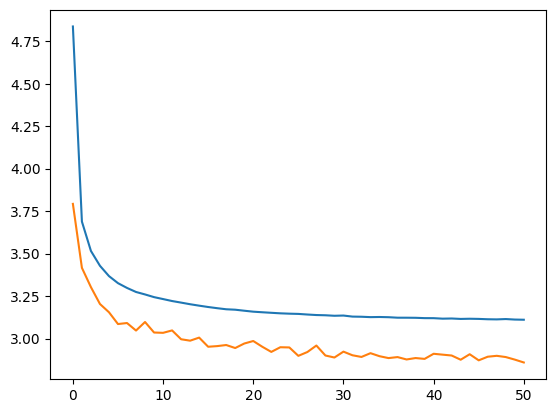

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

#All frozen except BN

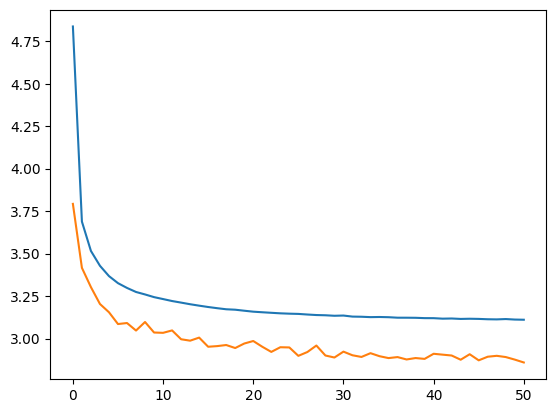

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

# All frozen; except last layer

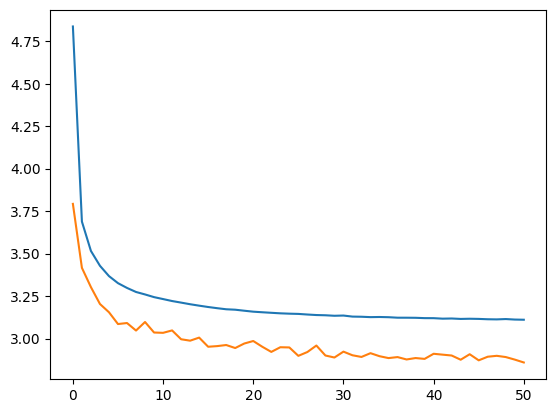

In [26]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

#All + last layer tuned

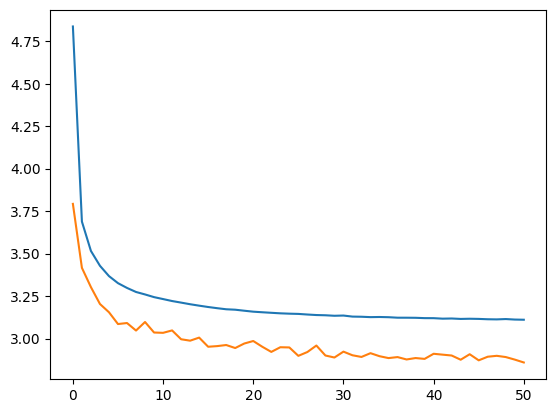

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

#BN + LL fine-tuned

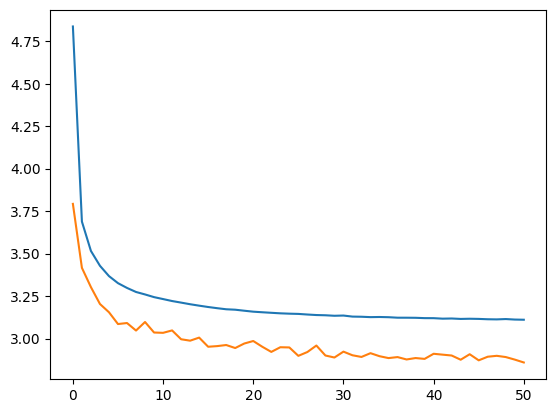

In [28]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

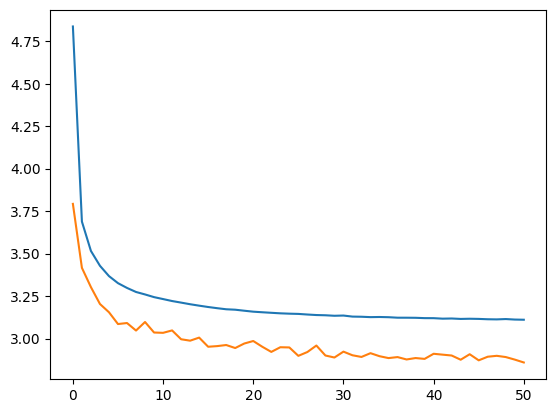

In [29]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

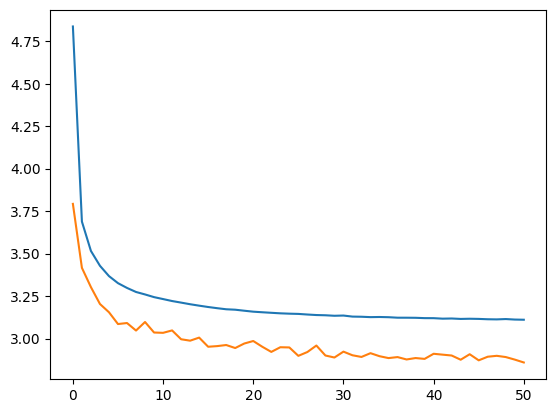

In [30]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

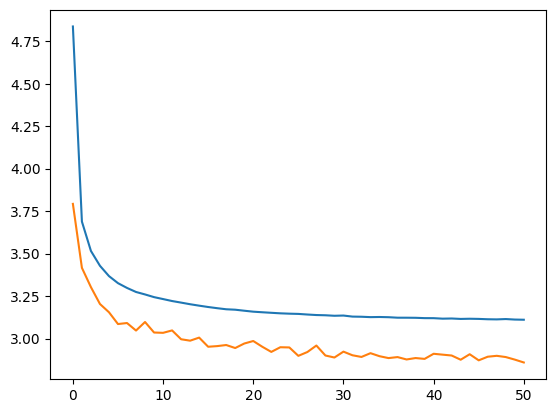

In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

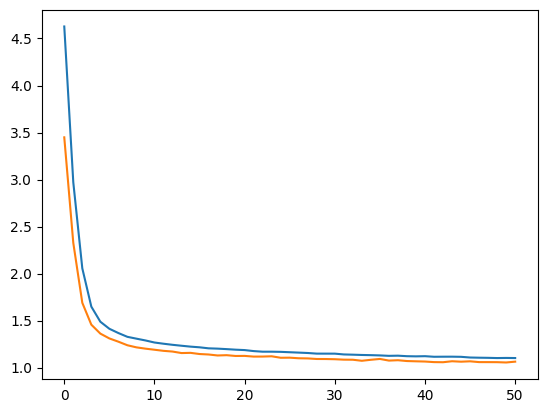

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

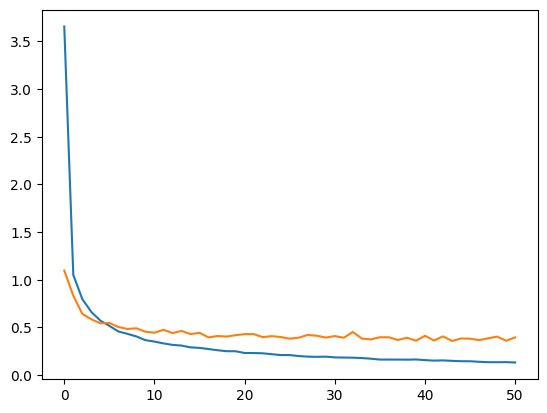

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

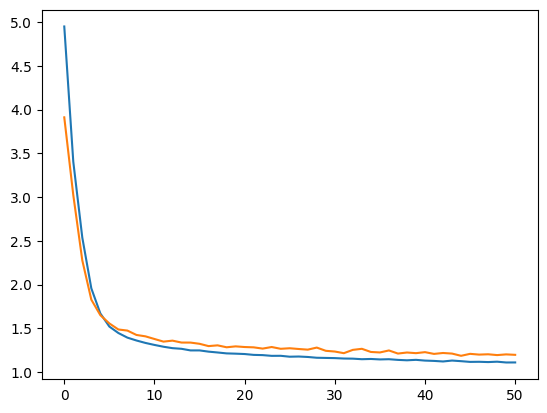

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

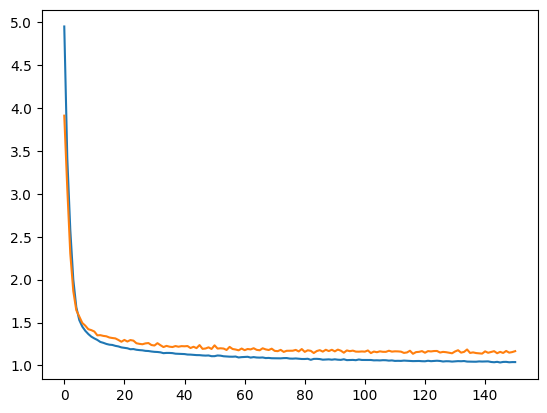

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

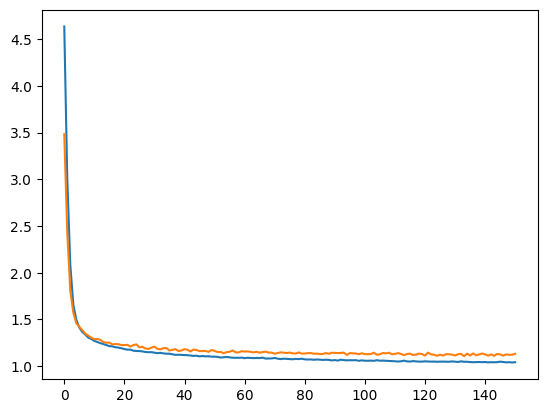

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

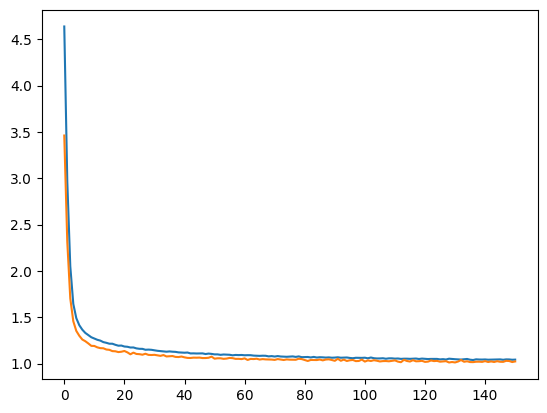

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

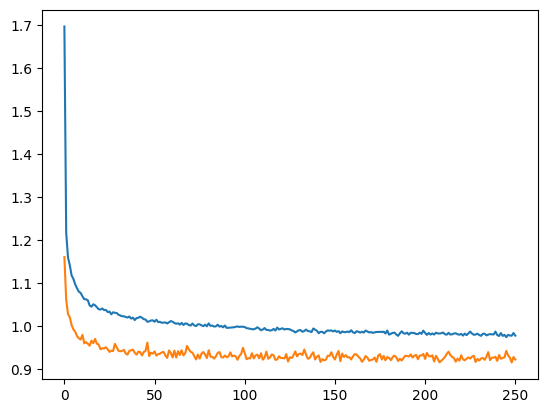

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.plot(train_loss)
plt.plot(val_loss)
plt.show()

In [ ]:
def cmp_test(trainloader,net):
  running_loss = 0.0
  with torch.no_grad():
      for data in tqdm(trainloader,disable=True):
          antenna, spectrum = data

          if torch.cuda.is_available():
              antenna, spectrum = antenna.cuda(), spectrum.cuda()

          # forward + backward + optimize
          prediction = net(antenna)
          loss = criterion(prediction, spectrum)

          # print statistics
          running_loss += loss.item()
          imgplot = plt.figure(figsize=(14,5))

          plt.subplot(1, 2, 1)
          imgplot= plt.plot(spectrum[2,:].cpu())
          imgplot= plt.plot(prediction[2,:].cpu())
          imgplot= plt.legend(['True','Prediction'])

          plt.subplot(1, 2, 2)
          imgplot = plt.imshow((antenna[2,0,:,:].cpu()))

          # print((antenna[2,0,:,:].cpu()))
          #plt.savefig('Test1.png')
          plt.show()

          break;

  return running_loss / (len(testloader))

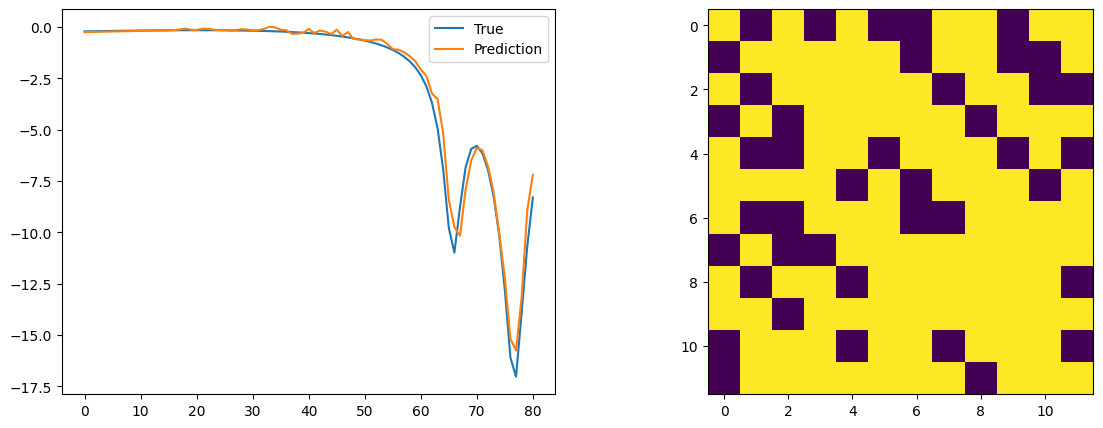

0.009442814625799656

In [ ]:
cmp_test(trainloader,net)

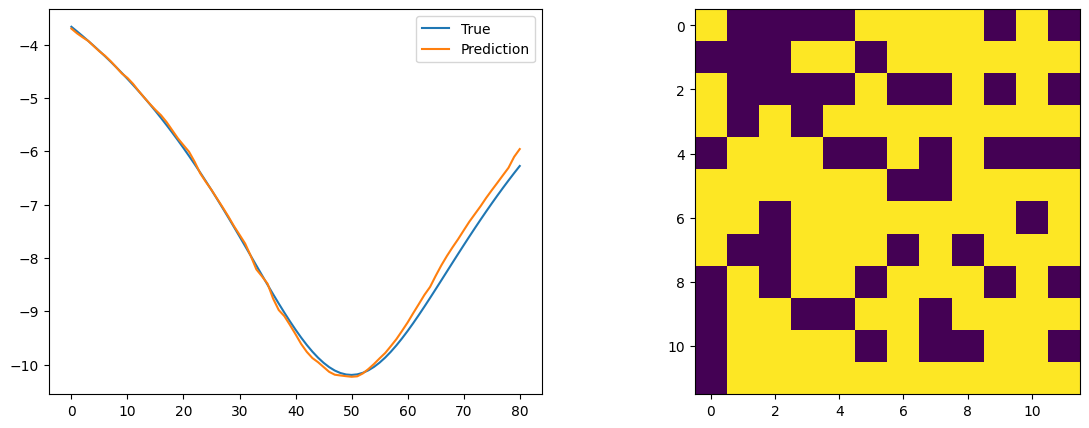

0.015064725652337074

In [ ]:
cmp_test(trainloader,net)

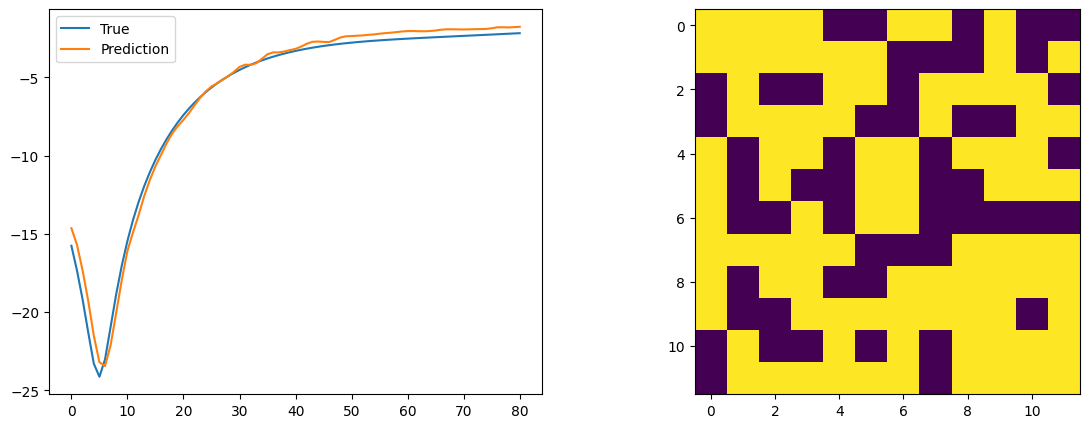

0.01649540103971958

In [ ]:
cmp_test(trainloader,net)

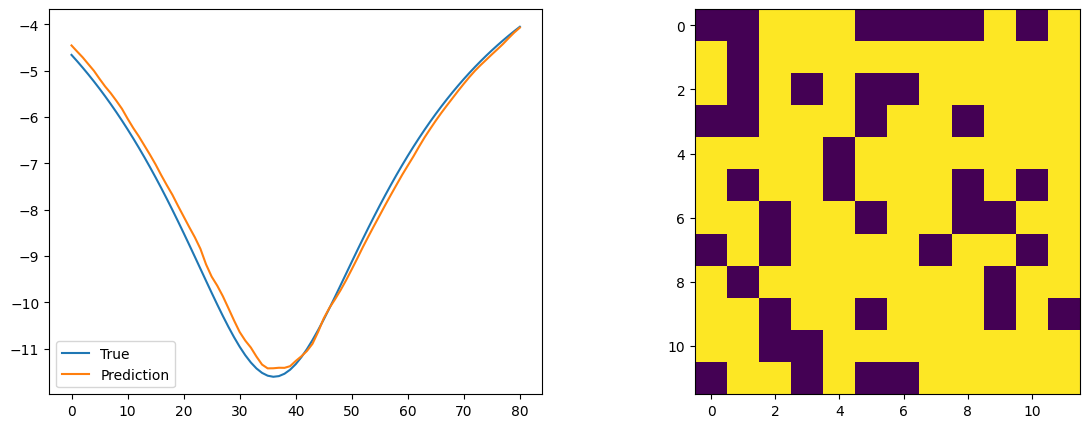

0.012578878551721573

In [ ]:
cmp_test(trainloader,net)

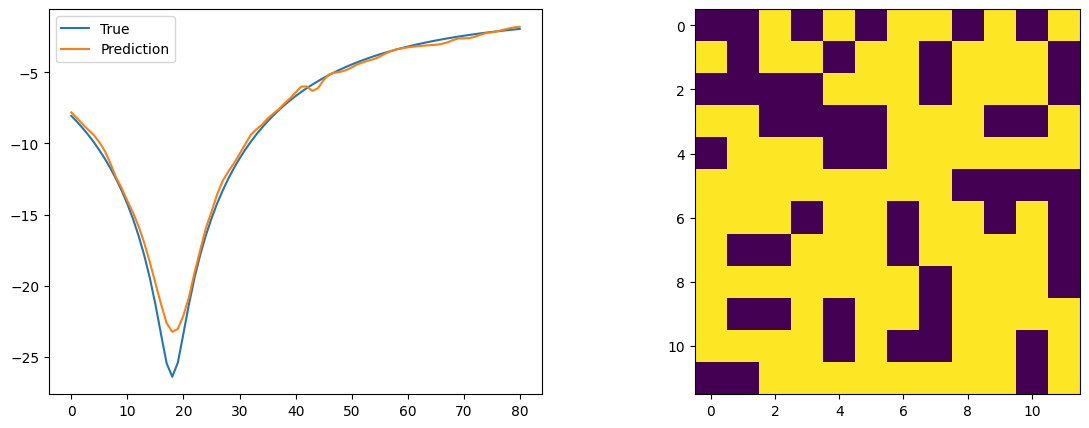

0.043433643877506256

In [ ]:
cmp_test(trainloader,net)

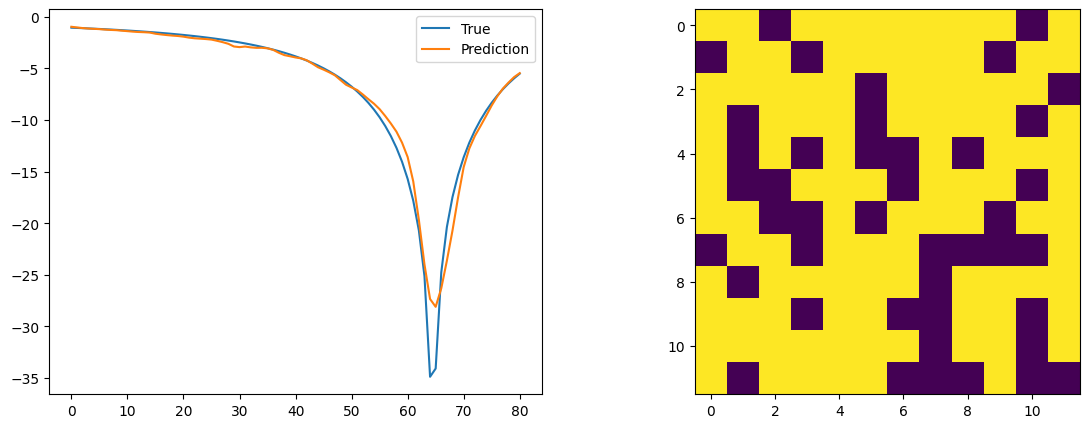

0.0068004983477294445

In [ ]:
cmp_test(trainloader,net)

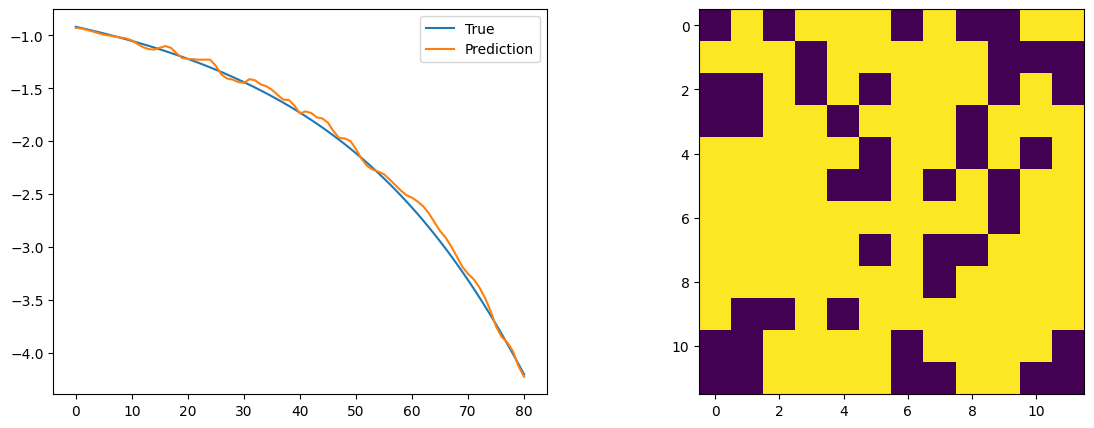

0.03445388004183769

In [ ]:
cmp_test(trainloader,net)

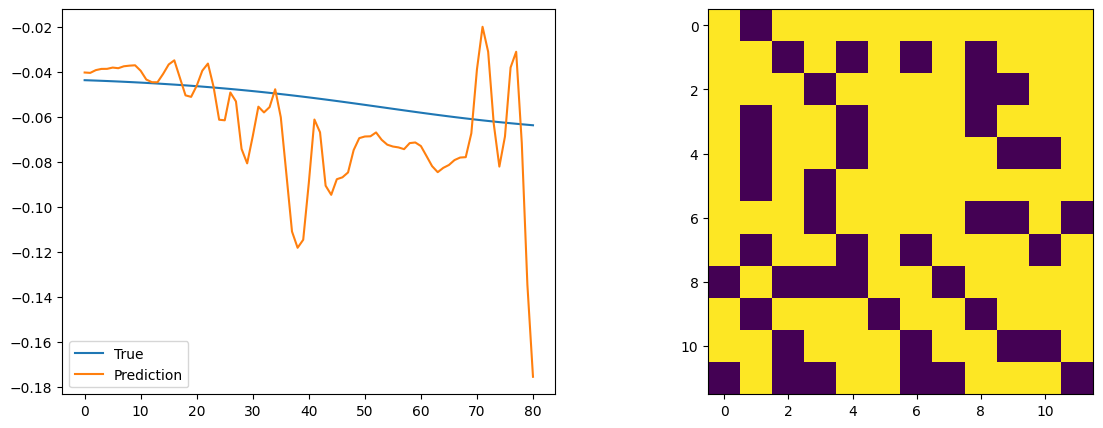

0.00015779583191033453

In [ ]:
cmp_test(trainloader,net)

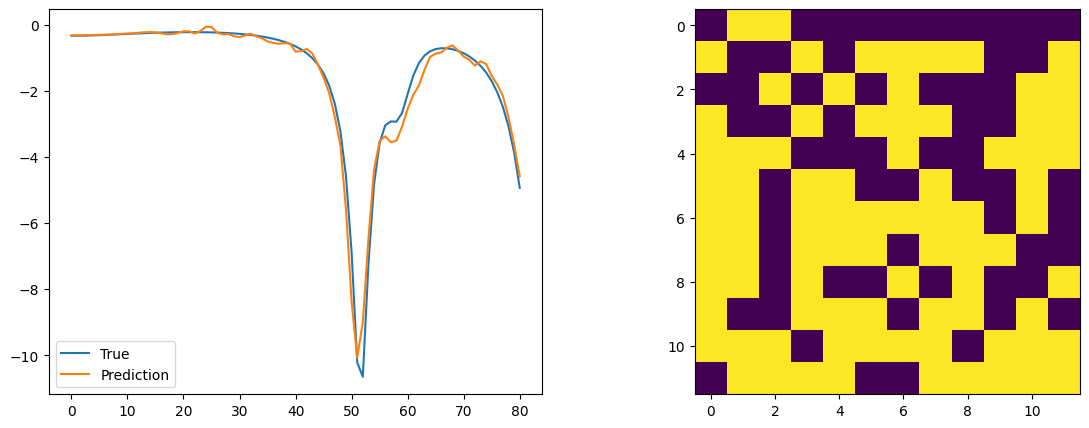

0.02554030530154705

In [ ]:
cmp_test(trainloader,net)

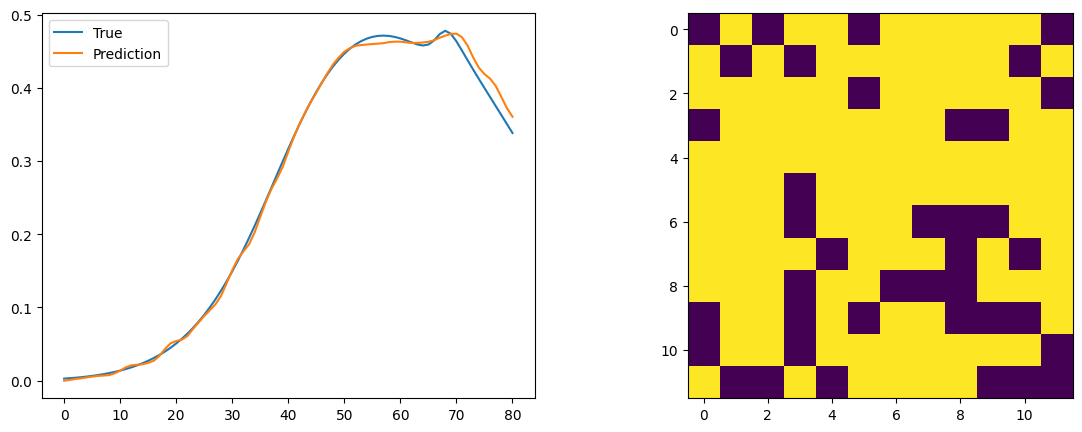

6.78769065416418e-05

In [ ]:
cmp_test(trainloader,net)

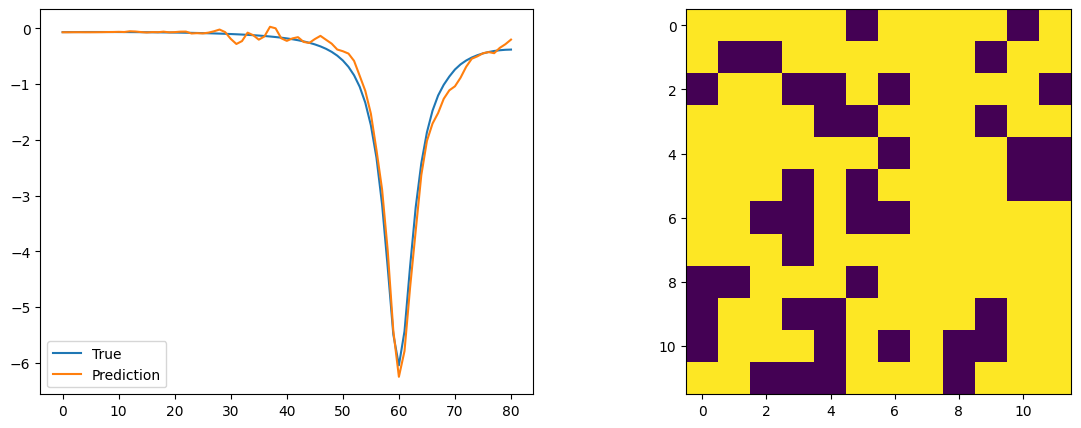

0.06064164265990257

In [ ]:
cmp_test(trainloader,net)

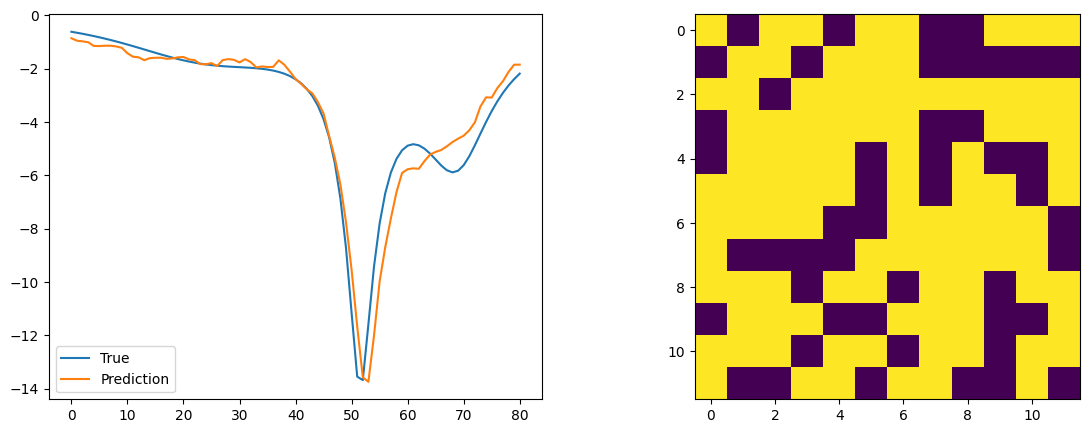

0.03535632540782293

In [ ]:
cmp_test(trainloader,net)

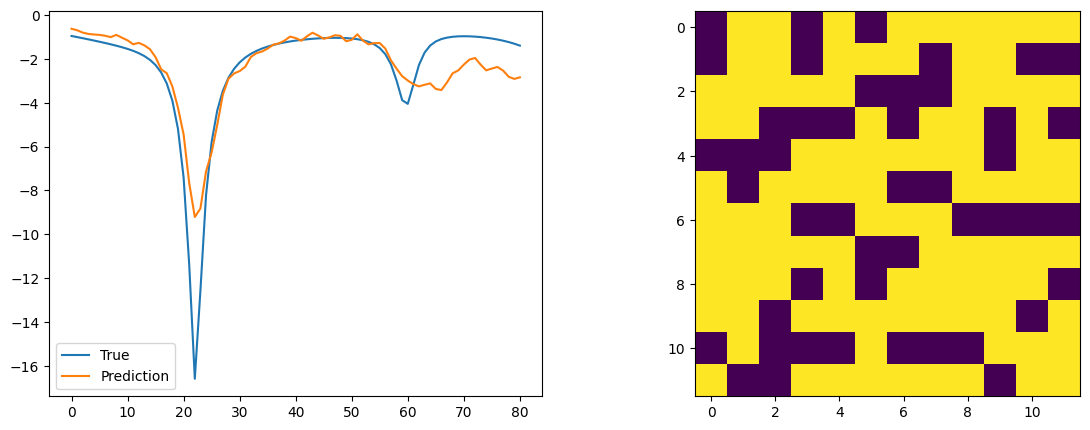

0.1444743126630783

In [ ]:
cmp_test(trainloader,net)

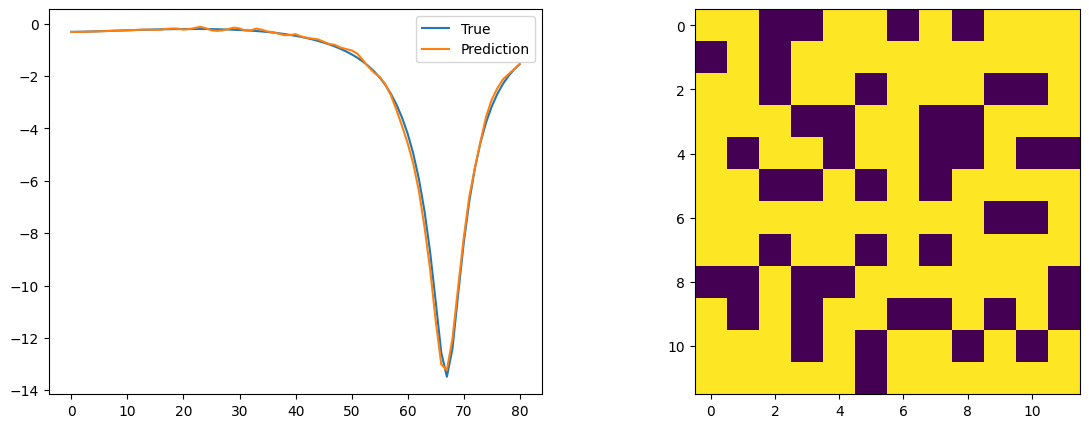

0.0018976511089665116

In [ ]:
cmp_test(trainloader,net)

In [ ]:
def cmp_test(testloader,net):
  running_loss = 0.0
  with torch.no_grad():
      for data in tqdm(testloader,disable=True):
          antenna, spectrum = data

          if torch.cuda.is_available():
              antenna, spectrum = antenna.cuda(), spectrum.cuda()

          # forward + backward + optimize
          prediction = net(antenna)
          loss = criterion(prediction, spectrum)

          # print statistics
          running_loss += loss.item()
          imgplot = plt.figure(figsize=(14,5))

          plt.subplot(1, 2, 1)
          imgplot= plt.plot(spectrum[2,:].cpu())
          imgplot= plt.plot(prediction[2,:].cpu())
          imgplot= plt.legend(['True','Prediction'])

          plt.subplot(1, 2, 2)
          imgplot = plt.imshow((antenna[2,0,:,:].cpu()))

          # print((antenna[2,0,:,:].cpu()))
          #plt.savefig('Test1.png')
          plt.show()

          break;

  return running_loss / (len(testloader))

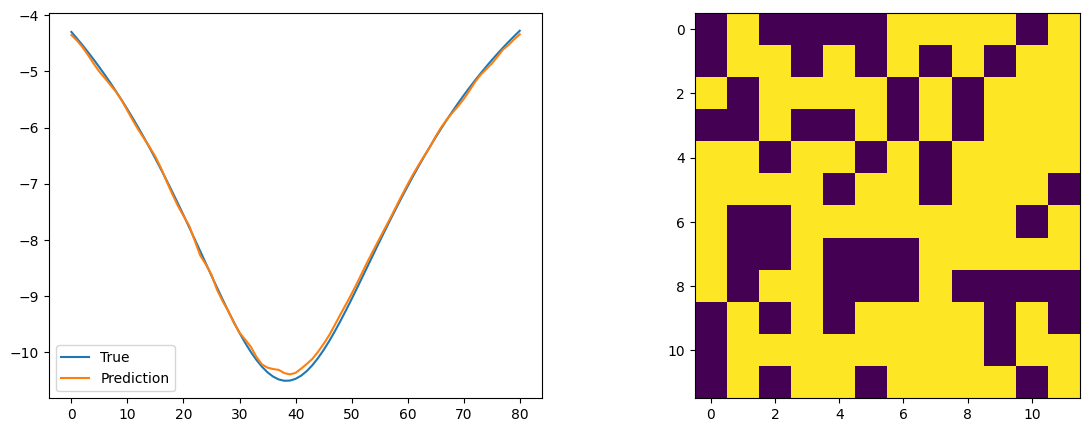

0.039577972143888474

In [ ]:
cmp_test(testloader,net)

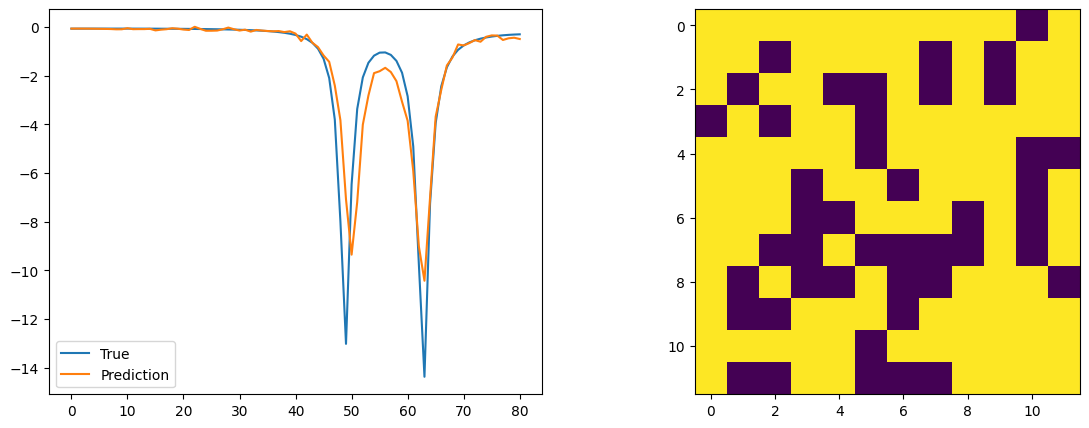

0.14417530596256256

In [ ]:
cmp_test(testloader,net)

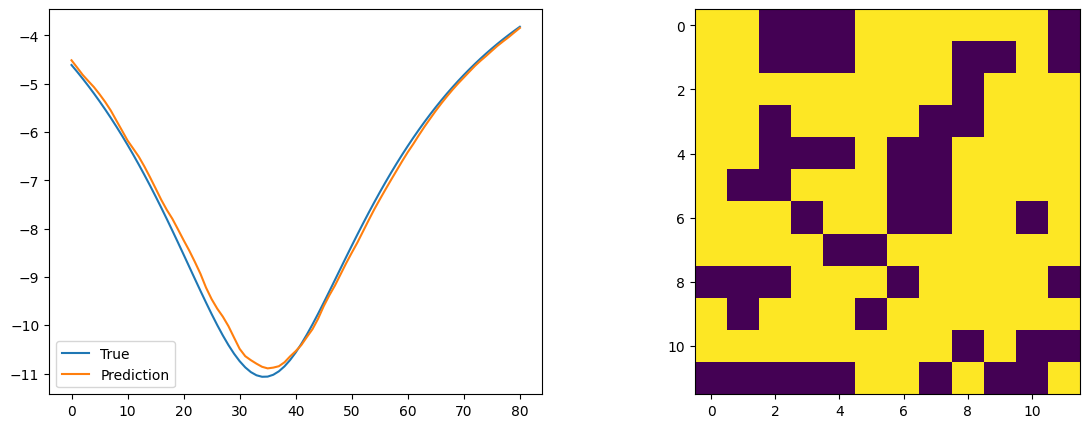

0.031035561114549637

In [ ]:
cmp_test(testloader,net)

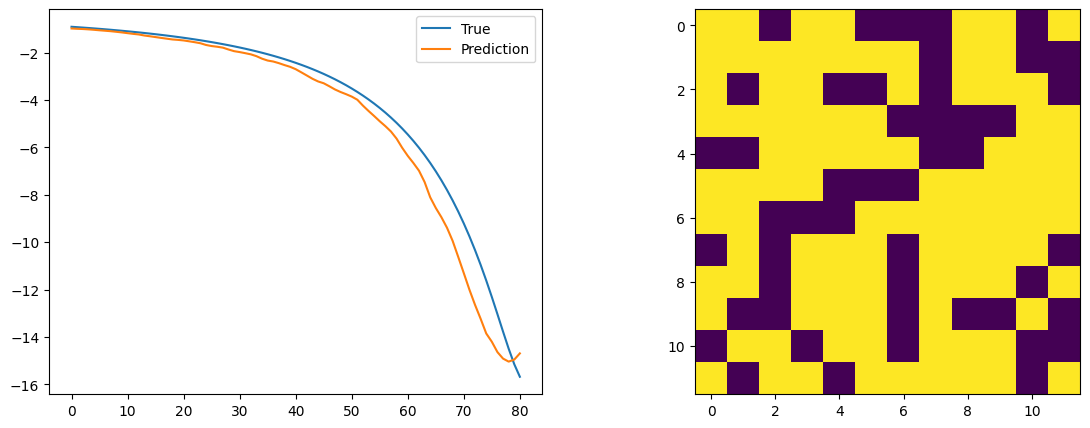

0.05395030975341797

In [ ]:
cmp_test(testloader,net)

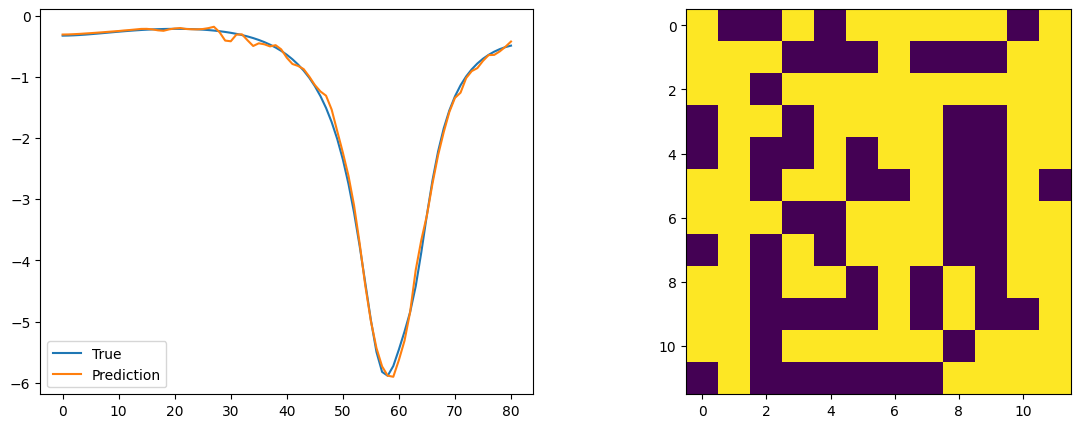

0.059681929647922516

In [ ]:
cmp_test(testloader,net)

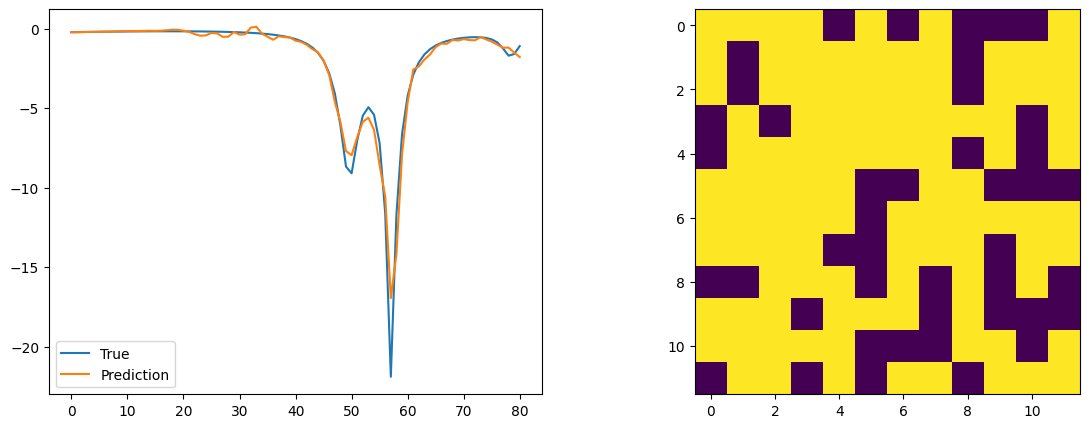

0.06970557570457458

In [ ]:
cmp_test(testloader,net)

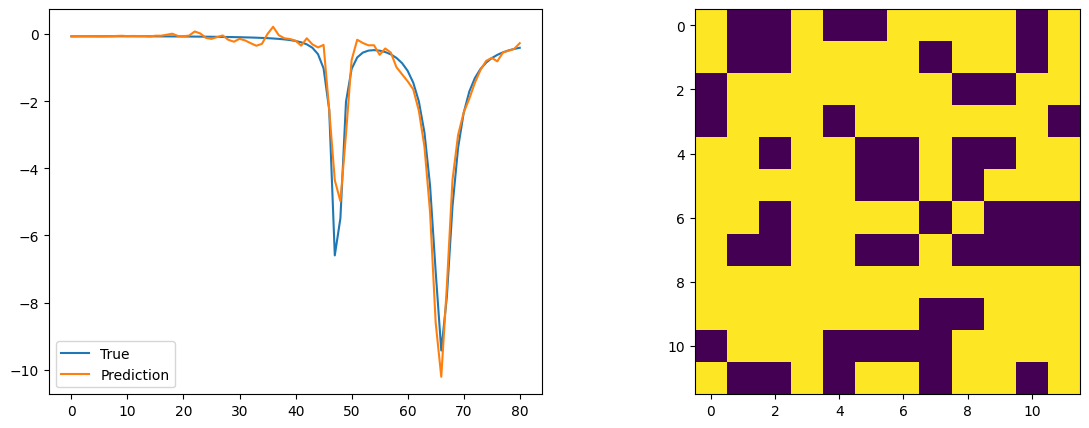

0.14524343609809875

In [ ]:
cmp_test(testloader,net)

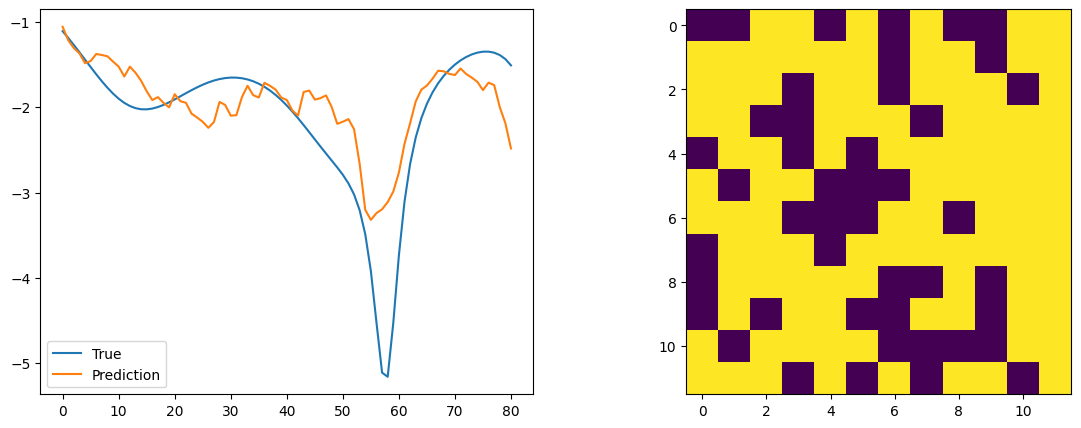

0.03821151206890742

In [ ]:
cmp_test(testloader,net)

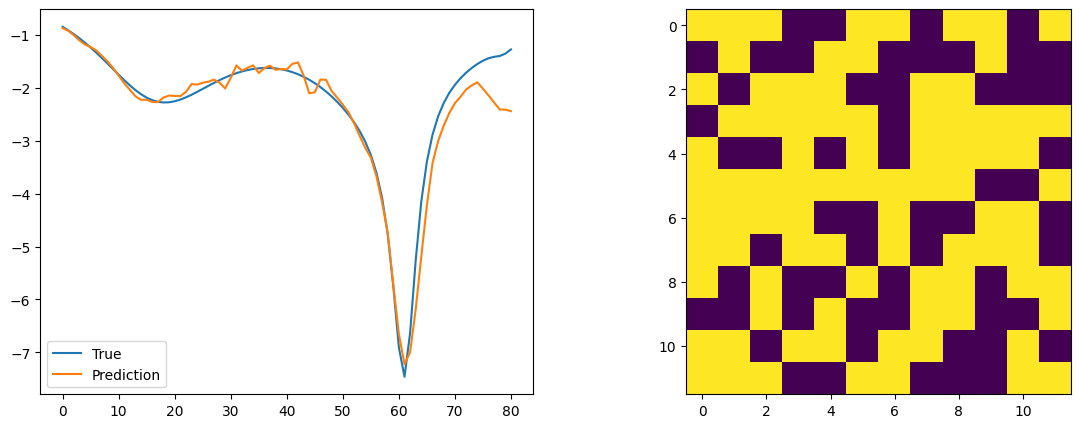

0.03867208957672119

In [ ]:
cmp_test(testloader,net)

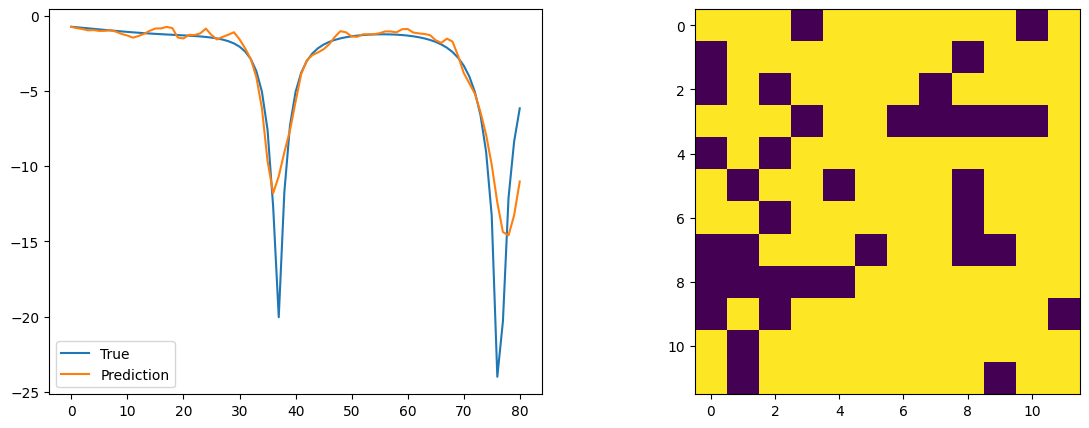

0.1458764523267746

In [ ]:
cmp_test(testloader,net)

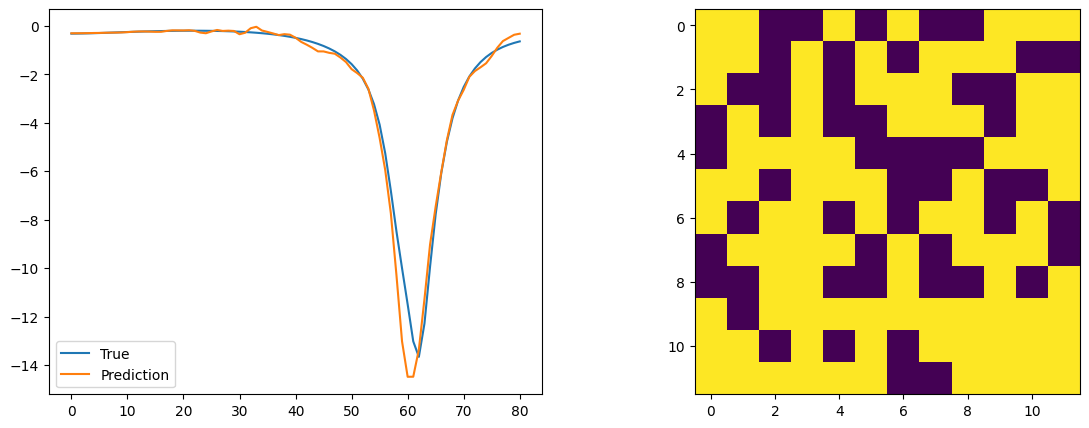

0.07191524654626846

In [ ]:
cmp_test(testloader,net)

In [ ]:
import matplotlib.pyplot as plt
def cmp_test(test_data,criterion1,net_inv,net):
  running_loss = 0.0
  with torch.no_grad():
      for data in tqdm(test_data,disable=True):
          antenna, spectrum = data

          if torch.cuda.is_available():
              antenna, spectrum = antenna.cuda(), spectrum.cuda()

          # forward + backward + optimize
          ant_pred = net_inv(spectrum)
          antenna_pred = ant_pred.reshape(ant_pred.shape[0],1,12,12)
          # imgplot = plt.imshow(np.array(antenna_pred[2,0,:,:]))
          # plt.show()
          # print(antenna_pred[0,:,:,:])
          spectrum_pred = net(antenna_pred)
          loss1 = criterion1(spectrum_pred, spectrum)
          # loss1 = loss_xu(spectrum_pred, spectrum, antenna_pred, antenna, alpha)

          # print statistics
          running_loss += loss1.item()
          #spectrum_pred = spectrum_pred.T
          #spectrum = spectrum.T
          for i in range(100):

            imgplot = plt.figure(figsize=(14,5))

            plt.subplot(1, 3, 1)
            imgplot = plt.plot(spectrum[i,:].cpu())
            imgplot = plt.plot(spectrum_pred[i,:].cpu())
            plt.subplot(1, 3, 2)
            imgplot = plt.imshow((antenna[i,0,:,:].cpu()))
            plt.subplot(1, 3, 3)
            imgplot = plt.imshow((antenna_pred[i,0,:,:].cpu()))
            plt.show()
            print(antenna_pred[i,0,:,:])
            print(antenna[i,0,:,:])

            ants = antenna_pred[i,0,:,:]
          break;

  return  ants

In [ ]:
x1= cmp_test(testloader,criterion1,net_inv,net)

NameError: ignored

In [ ]:
xtrain = xdata[1:10,:,:,:]
int2 = torch.zeros([xtrain.shape[0],1,12,12])
x1 = torch.FloatTensor(xtrain)
antenna = net(int2[1:3,:,:,:])

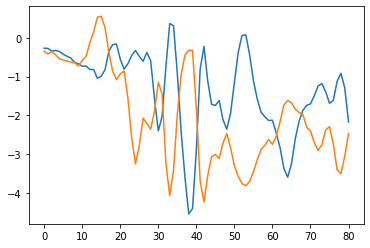

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]])


In [ ]:
plt.plot(antenna.detach().numpy()[0,:])
plt.plot(antenna.detach().numpy()[1,:])
plt.show()
print(int2[8,:,:,:])

In [ ]:
# Commands used to reset the layers of the trained network
for layers in net.children():
    if hasattr(layers, 'reset_parameters'):
        layers.reset_parameters()



In [ ]:
 train_loss_inv[epoch], val_loss_inv[epoch])

SyntaxError: ignored

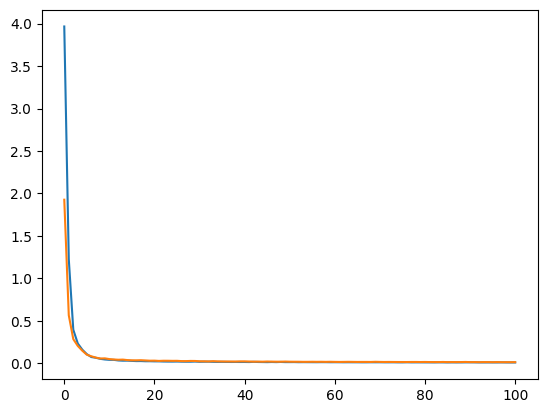

In [ ]:
plt.plot(train_loss)
plt.plot(val_loss)



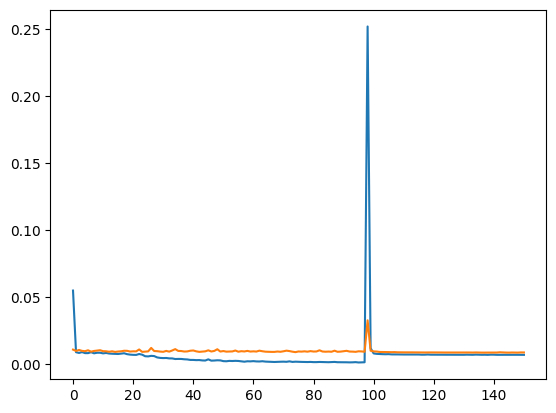

In [ ]:
plt.plot(train_loss)
plt.plot(val_loss)

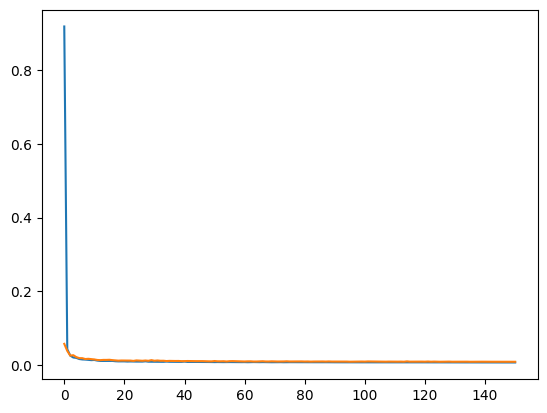

In [ ]:
plt.plot(train_loss)
plt.plot(val_loss)

In [ ]:
import torch
A = torch.rand(2,2)
print(A)
B = torch.rand(2,2)
print(B)

torch.mul(A,B)

tensor([[0.8124, 0.2703],
        [0.7849, 0.2245]])
tensor([[0.0785, 0.5473],
        [0.6933, 0.6592]])


tensor([[0.0638, 0.1479],
        [0.5442, 0.1480]])

In [ ]:
0.2703*0.5473


0.14793519